In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [30]:
df = pd.read_csv("used_cars.csv")

df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [34]:
df.shape 



(4009, 12)

In [32]:
df.columns

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='str')

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 892.6 KB


In [36]:
df.isnull().sum()


brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [37]:
df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

df["price"].head()

0    10300.0
1    38005.0
2    54598.0
3    15500.0
4    34999.0
Name: price, dtype: float64

In [38]:
df["milage"] = (
    df["milage"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace(" mi.", "", regex=False)
    .astype(float)
)

df["milage"].head()

0    51000.0
1    34742.0
2    22372.0
3    88900.0
4     9835.0
Name: milage, dtype: float64

In [39]:
df.describe()

,model_year,milage,price
count,4009.000000,4009.000000,4.009000e+03
mean,2015.515590,64717.551010,4.455319e+04
std,6.104816,52296.599459,7.871064e+04
min,1974.000000,100.000000,2.000000e+03
25%,2012.000000,23044.000000,1.720000e+04
50%,2017.000000,52775.000000,3.100000e+04
75%,2020.000000,94100.000000,4.999000e+04
max,2024.000000,405000.000000,2.954083e+06


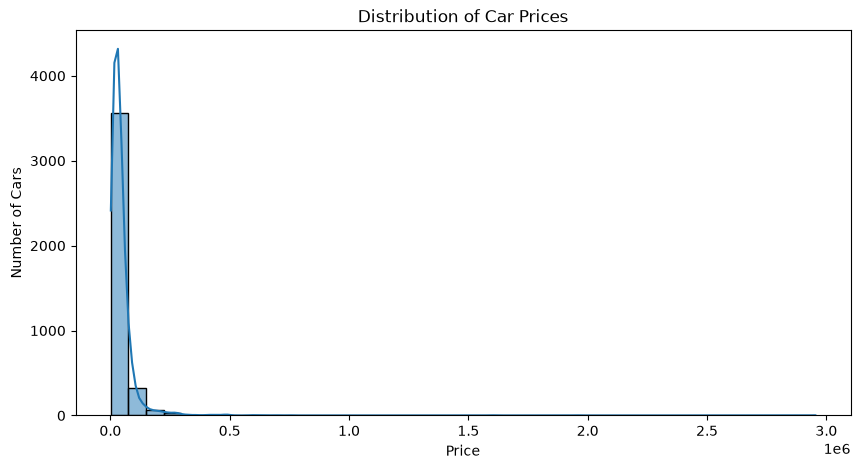

In [40]:
plt.figure(figsize=(10, 5))

sns.histplot(df["price"], bins=40, kde=True)

plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Number of Cars")
plt.show()

In [41]:
numeric_cols = ["model_year", "milage", "price"]

df[numeric_cols].corr()

,model_year,milage,price
model_year,1.000000,-0.617720,0.199496
milage,-0.617720,1.000000,-0.305528
price,0.199496,-0.305528,1.000000


In [42]:
X = df.drop("price", axis=1)
y = df["price"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (4009, 11)
y shape: (4009,)


In [43]:
numerical_features = [
    "model_year",
    "milage"
]

categorical_features = [
    "brand",
    "model",
    "fuel_type",
    "engine",
    "transmission",
    "ext_col",
    "int_col",
    "accident",
    "clean_title"
]

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['model_year', 'milage']

Categorical features:
['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title']


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3207, 11)
Testing data: (802, 11)


In [46]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)




In [48]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)


In [49]:
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print("MAE :", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R2  :", round(linear_r2, 4))


MAE : 19744.9
RMSE: 138034.55
R2  : 0.0678


In [51]:
svr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", SVR(kernel="rbf"))
    ]
)

svr_model.fit(X_train, y_train)

svr_pred = svr_model.predict(X_test)


In [52]:
svr_mae = mean_absolute_error(y_test, svr_pred)
svr_rmse = np.sqrt(mean_squared_error(y_test, svr_pred))
svr_r2 = r2_score(y_test, svr_pred)

print("MAE :", round(svr_mae, 2))
print("RMSE:", round(svr_rmse, 2))
print("R2  :", round(svr_r2, 4))

MAE : 32779.68
RMSE: 144195.03
R2  : -0.0173


In [53]:
dt_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            max_depth=15,
            random_state=42
        ))
    ]
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)


In [54]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("MAE :", round(dt_mae, 2))
print("RMSE:", round(dt_rmse, 2))
print("R2  :", round(dt_r2, 4))

MAE : 22870.82
RMSE: 137159.04
R2  : 0.0796


In [56]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=20,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)



In [57]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R2  :", round(rf_r2, 4))

MAE : 20118.6
RMSE: 134892.83
R2  : 0.1098


In [59]:
bagging_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", BaggingRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

bagging_model.fit(X_train, y_train)

bagging_pred = bagging_model.predict(X_test)



In [60]:
bagging_mae = mean_absolute_error(y_test, bagging_pred)
bagging_rmse = np.sqrt(mean_squared_error(y_test, bagging_pred))
bagging_r2 = r2_score(y_test, bagging_pred)

print("MAE :", round(bagging_mae, 2))
print("RMSE:", round(bagging_rmse, 2))
print("R2  :", round(bagging_r2, 4))


MAE : 19038.52
RMSE: 134817.44
R2  : 0.1108


In [62]:
boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

boosting_model.fit(X_train, y_train)

boosting_pred = boosting_model.predict(X_test)


In [63]:
boosting_mae = mean_absolute_error(y_test, boosting_pred)
boosting_rmse = np.sqrt(mean_squared_error(y_test, boosting_pred))
boosting_r2 = r2_score(y_test, boosting_pred)

print("MAE :", round(boosting_mae, 2))
print("RMSE:", round(boosting_rmse, 2))
print("R2  :", round(boosting_r2, 4))


MAE : 23292.27
RMSE: 135858.78
R2  : 0.097


In [64]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "SVR",
        "Decision Tree",
        "Random Forest",
        "Bagging",
        "Boosting"
    ],
    "MAE": [
        linear_mae,
        svr_mae,
        dt_mae,
        rf_mae,
        bagging_mae,
        boosting_mae
    ],
    "RMSE": [
        linear_rmse,
        svr_rmse,
        dt_rmse,
        rf_rmse,
        bagging_rmse,
        boosting_rmse
    ],
    "R2": [
        linear_r2,
        svr_r2,
        dt_r2,
        rf_r2,
        bagging_r2,
        boosting_r2
    ]
})

results.sort_values("R2", ascending=False)

,Model,MAE,RMSE,R2
4,Bagging,19038.518766,134817.442166,0.110757
3,Random Forest,20118.599037,134892.828335,0.109762
5,Boosting,23292.270214,135858.782971,0.096967
2,Decision Tree,22870.818008,137159.041970,0.079599
0,Linear Regression,19744.895889,138034.550676,0.067811
1,SVR,32779.681830,144195.034662,-0.017253


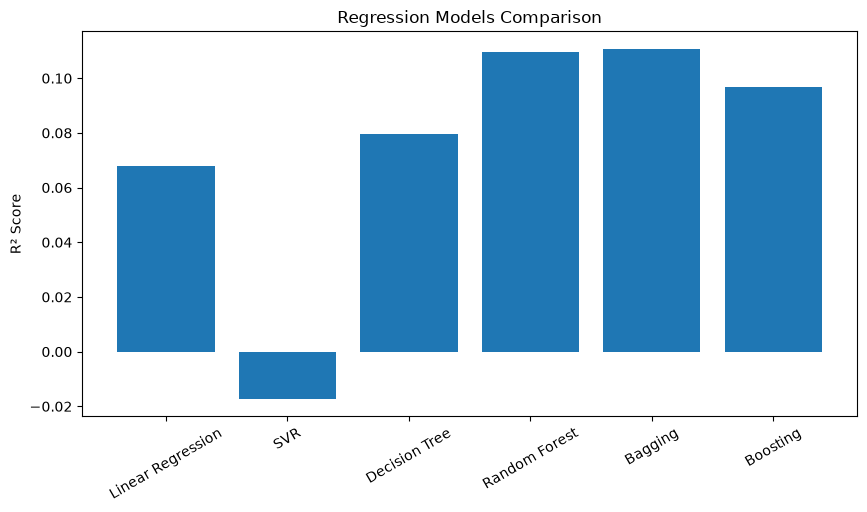

In [65]:
plt.figure(figsize=(10, 5))

plt.bar(results["Model"], results["R2"])

plt.xticks(rotation=30)
plt.ylabel("R² Score")
plt.title("Regression Models Comparison")
plt.show()

In [66]:
best_model_name = results.loc[
    results["R2"].idxmax(), "Model"
]

best_model_r2 = results["R2"].max()

print("Best Model:", best_model_name)
print("Best R2:", round(best_model_r2, 4))

Best Model: Bagging
Best R2: 0.1108


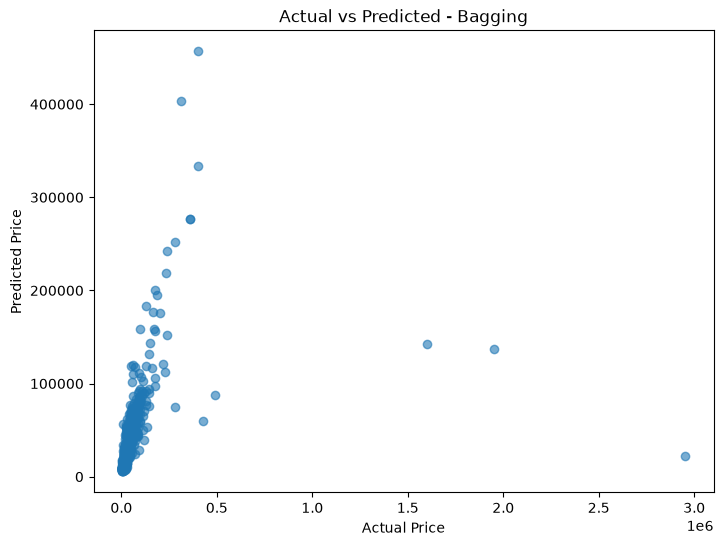

In [67]:
best_predictions = {
    "Linear Regression": linear_pred,
    "SVR": svr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "Bagging": bagging_pred,
    "Boosting": boosting_pred
}

best_pred = best_predictions[best_model_name]

plt.figure(figsize=(8, 6))

plt.scatter(y_test, best_pred, alpha=0.6)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted - {best_model_name}")

plt.show()

In [68]:
#CLASSFCATION
q1 = df["price"].quantile(0.33)
q2 = df["price"].quantile(0.66)

print("Budget upper limit :", q1)
print("Medium upper limit :", q2)

Budget upper limit : 21500.0
Medium upper limit : 42000.0


In [69]:
def price_category(price):
    if price <= q1:
        return "Budget"
    elif price <= q2:
        return "Medium"
    else:
        return "Premium"


df["price_category"] = df["price"].apply(price_category)

df[["price", "price_category"]].head(10)

,price,price_category
0,10300.0,Budget
1,38005.0,Medium
2,54598.0,Premium
3,15500.0,Budget
4,34999.0,Medium
5,14798.0,Budget
6,31000.0,Medium
7,7300.0,Budget
8,41927.0,Medium
9,69950.0,Premium


In [70]:
df["price_category"].value_counts()


price_category
Premium    1354
Budget     1339
Medium     1316
Name: count, dtype: int64

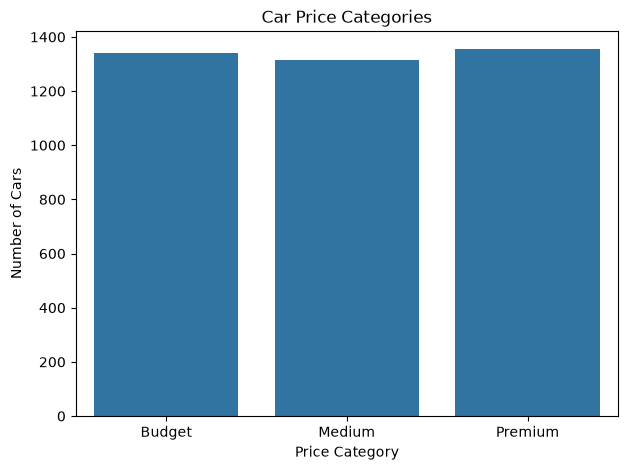

In [71]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="price_category")

plt.title("Car Price Categories")
plt.xlabel("Price Category")
plt.ylabel("Number of Cars")
plt.show()


In [72]:
X_class = df.drop(["price", "price_category"], axis=1)
y_class = df["price_category"]

print("X shape:", X_class.shape)
print("y shape:", y_class.shape)

X shape: (4009, 11)
y shape: (4009,)
